In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import glob
import os
import io
from pathlib import Path

# Figure output directory
FIG_Q1 = Path("../reports/figures/p1")
FIG_Q1.mkdir(parents=True, exist_ok=True)


def parse_mcperf_file(filepath):
    """Parse a single mcperf log and return a cleaned DataFrame."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    table_lines = [l for l in lines if l.startswith('#') or l.startswith('read')]
    df = pd.read_csv(io.StringIO("".join(table_lines)), sep=r'\s+')
    df.columns = [c.replace('#', '') for c in df.columns]
    df['p95_ms'] = df['p95'] / 1000.0
    return df[['target', 'QPS', 'p95_ms']]


# Load all runs
INTERFERENCE_TYPES = ['baseline', 'cpu', 'l1d', 'l1i', 'l2', 'llc', 'membw']
DISPLAY_NAMES = {
    'baseline': 'No interference',
    'cpu':      'CPU',
    'l1d':      'L1 Data Cache',
    'l1i':      'L1 Instruction Cache',
    'l2':       'L2 Cache',
    'llc':      'LLC Cache',
    'membw':    'Memory Bandwidth',
}
SLO_MS = 0.8

all_data = []
for file in glob.glob("../data/part-1/*.log"):
    config_name = os.path.basename(file).split('-')[0]
    if config_name in INTERFERENCE_TYPES:
        df = parse_mcperf_file(file)
        df['config'] = config_name
        all_data.append(df)

master_df = pd.concat(all_data, ignore_index=True)

# Mean and std across 3 runs, grouped by interference type and target QPS
stats = master_df.groupby(['config', 'target']).agg(
    qps_mean=('QPS',    'mean'),
    qps_std= ('QPS',    'std'),
    run_count=('QPS',   'count'),
    p95_mean= ('p95_ms','mean'),
    p95_std=  ('p95_ms','std'),
).reset_index()

print(f"Loaded {len(all_data)} log files across {master_df['config'].nunique()} interference types.")
print(f"QPS steps per run: {master_df['target'].nunique()}  |  Runs per type: {stats['run_count'].max()}")

Loaded 21 log files across 7 interference types.
QPS steps per run: 16  |  Runs per type: 3


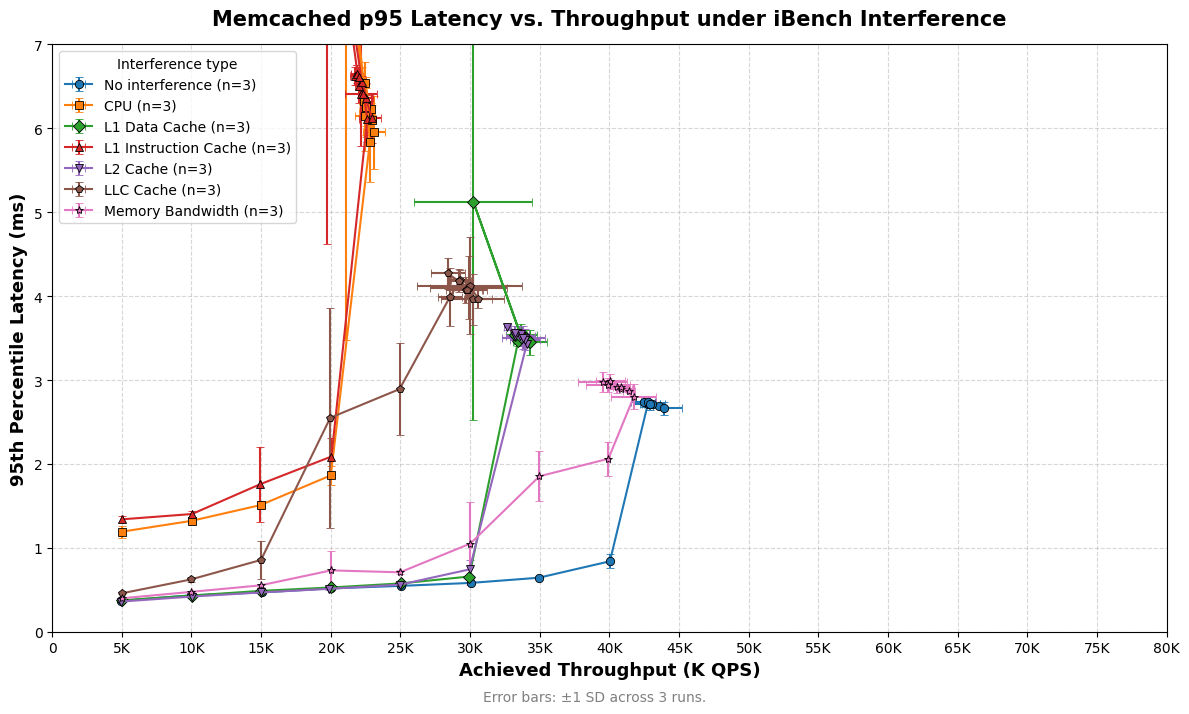

In [8]:
# Plot: p95 latency vs. achieved QPS
cmap    = mpl.colormaps['tab10']
markers = ['o', 's', 'D', '^', 'v', 'p', '*']

fig, ax = plt.subplots(figsize=(12, 7))

for i, config in enumerate(INTERFERENCE_TYPES):
    subset = stats[stats['config'] == config].sort_values('target')
    if subset.empty:
        continue
    num_runs  = int(subset['run_count'].iloc[0])
    label     = f"{DISPLAY_NAMES.get(config, config)} (n={num_runs})"

    ax.errorbar(
        subset['qps_mean'] / 1000,
        subset['p95_mean'],
        xerr=subset['qps_std'] / 1000,
        yerr=subset['p95_std'],
        label=label,
        marker=markers[i % len(markers)],
        markersize=6,
        markeredgecolor='black',
        markeredgewidth=0.6,
        capsize=3,
        linestyle='-',
        linewidth=1.5,
        color=cmap(i),
    )

ax.set_title('Memcached p95 Latency vs. Throughput under iBench Interference',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Achieved Throughput (K QPS)', fontsize=13, fontweight='bold')
ax.set_ylabel('95th Percentile Latency (ms)', fontsize=13, fontweight='bold')

ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: '0' if x == 0 else f'{x:.0f}K'))
ax.set_xlim(0, 80)
ax.set_xticks(np.arange(0, 81, 5))
ax.set_ylim(0, 7)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(title='Interference type', loc='upper left', frameon=True, fontsize=10)

fig.text(0.5, -0.01, 'Error bars: ±1 SD across 3 runs.',
         ha='center', fontsize=10, color='grey')

plt.tight_layout()
plt.savefig(FIG_Q1 / 'part-1-a-latency.png', dpi=300, bbox_inches='tight')
plt.show()